# Nairobi Property Market — Geographic Analysis

Phase 5 puts the Phase 4 findings on a map of Nairobi.

We aggregate the 940 cleaned listings up to **sub-county level** using the
neighborhood -> sub-county lookup built via spatial geocoding (see `build_geo_lookup.py`).

Three choropleth maps:
1. Median sale price
2. Median monthly rent
3. Sale price per m²

Sub-counties without enough data are shown in grey.

*Yield is covered at neighborhood level in `03_analysis.ipynb` (Phase 4); a geographic
yield map was excluded because BRK's 2-bed apartment inventory only supports the
n>=10 threshold in 2 of the 17 Nairobi sub-counties.*

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../data/property.db")
listings = pd.read_sql_query("SELECT * FROM listings", conn)

lookup = pd.read_csv("../data/processed/neighborhood_to_subcounty.csv", comment="#")
listings = listings.merge(lookup[["neighborhood", "sub_county"]], on="neighborhood", how="left")

print(f"Total listings: {len(listings)}")
print(f"Listings mapped to a sub_county: {listings['sub_county'].notna().sum()}")
print(f"Listings outside Nairobi (excluded from maps): {listings['sub_county'].isna().sum()}")

polygons = gpd.read_file("../data/geo/nairobi_sub_counties.geojson")
print(f"Loaded {len(polygons)} sub-county polygons")

Total listings: 940
Listings mapped to a sub_county: 937
Listings outside Nairobi (excluded from maps): 3
Loaded 17 sub-county polygons


## Map 1 — Median sale price by sub-county

**Note on interpretation:** the median is taken across all property types (apartment, house, townhouse, villa). Sub-counties dominated by apartments — like **Westlands** and **Dagoretti North** — show lower medians than their reputation suggests, because apartment sales (~7–10M) vastly outnumber house sales (~70–150M) in those areas. Houses-only median for Westlands is ~120M; for Dagoretti North ~85M. The map shows the bulk of inventory, not the premium tier.

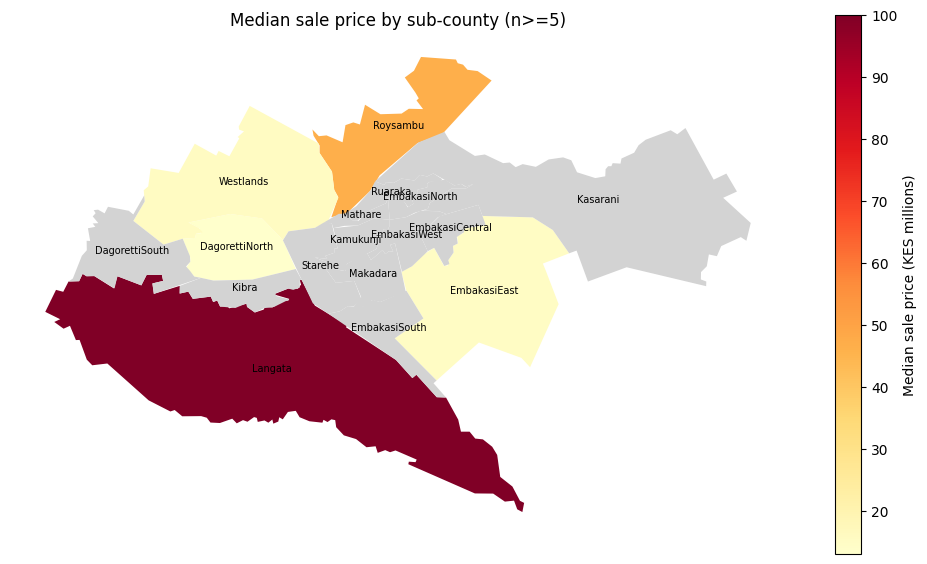

In [2]:
sale = listings[listings["type"] == "sale"]
agg = sale.groupby("sub_county")["price"].agg(["median", "count"]).reset_index()
agg = agg[agg["count"] >= 5]
agg["median_millions"] = agg["median"] / 1_000_000

map_data = polygons.merge(agg, on="sub_county", how="left")

fig, ax = plt.subplots(figsize=(10, 8))
map_data.plot(column="median_millions", ax=ax, legend=True,
              missing_kwds={"color": "lightgrey", "label": "No data"},
              cmap="YlOrRd",
              legend_kwds={"label": "Median sale price (KES millions)", "shrink": 0.7})
for _, row in map_data.iterrows():
    if row.geometry is not None:
        ax.annotate(row["sub_county"], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha="center", fontsize=7)
ax.set_title("Median sale price by sub-county (n>=5)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Map 2 — Median monthly rent by sub-county

Same property-mix caveat as Map 1: rentals in Roysambu/Lang'ata are mostly houses (250–400K), while Dagoretti North rentals are mostly apartments (~160K). Different property types dominate different sub-counties.

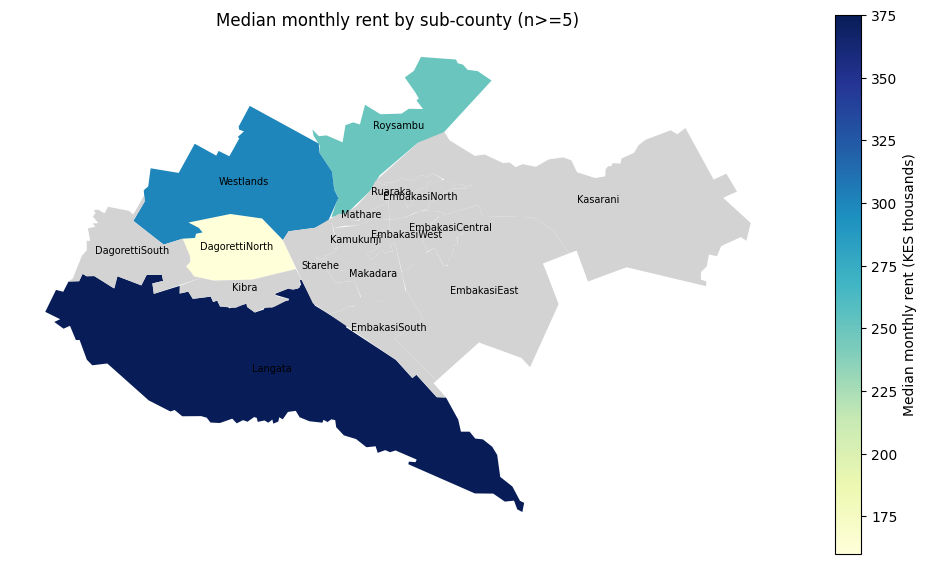

In [3]:
rent = listings[listings["type"] == "rent"]
agg = rent.groupby("sub_county")["price"].agg(["median", "count"]).reset_index()
agg = agg[agg["count"] >= 5]
agg["median_thousands"] = agg["median"] / 1_000

map_data = polygons.merge(agg, on="sub_county", how="left")

fig, ax = plt.subplots(figsize=(10, 8))
map_data.plot(column="median_thousands", ax=ax, legend=True,
              missing_kwds={"color": "lightgrey", "label": "No data"},
              cmap="YlGnBu",
              legend_kwds={"label": "Median monthly rent (KES thousands)", "shrink": 0.7})
for _, row in map_data.iterrows():
    if row.geometry is not None:
        ax.annotate(row["sub_county"], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha="center", fontsize=7)
ax.set_title("Median monthly rent by sub-county (n>=5)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Map 3 — Sale price per m² by sub-county

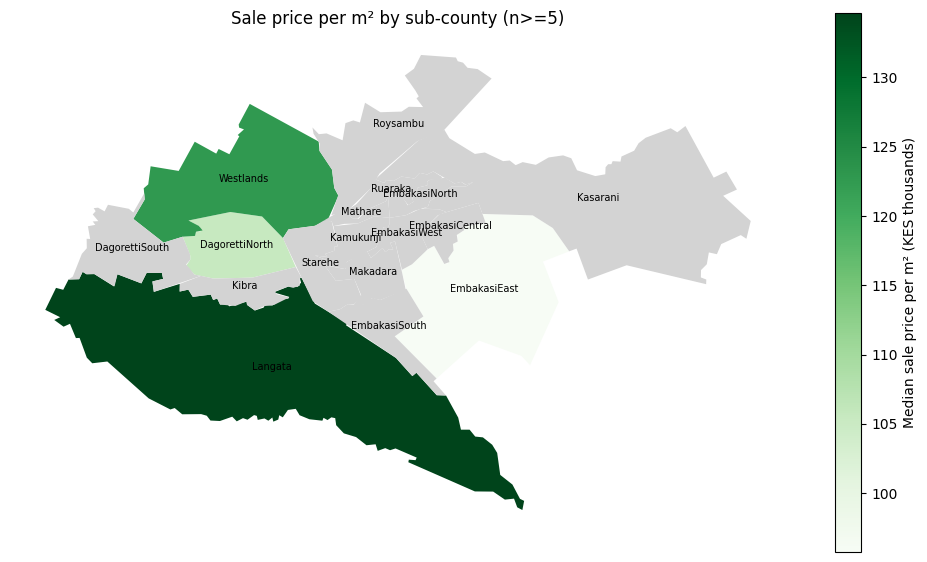

In [4]:
with_size = listings[(listings["type"] == "sale") & listings["size_m2"].notna()].copy()
with_size["price_per_m2"] = with_size["price"] / with_size["size_m2"]

agg = with_size.groupby("sub_county")["price_per_m2"].agg(["median", "count"]).reset_index()
agg = agg[agg["count"] >= 5]
agg["median_thousands"] = agg["median"] / 1_000

map_data = polygons.merge(agg, on="sub_county", how="left")

fig, ax = plt.subplots(figsize=(10, 8))
map_data.plot(column="median_thousands", ax=ax, legend=True,
              missing_kwds={"color": "lightgrey", "label": "No data"},
              cmap="Greens",
              legend_kwds={"label": "Median sale price per m² (KES thousands)", "shrink": 0.7})
for _, row in map_data.iterrows():
    if row.geometry is not None:
        ax.annotate(row["sub_county"], xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha="center", fontsize=7)
ax.set_title("Sale price per m² by sub-county (n>=5)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

Phase 5 places the Phase 4 findings on a map of Nairobi at sub-county level.
10 of 17 Nairobi sub-counties have listings in our dataset; the remaining 7
(Kamukunji, Kasarani, Mathare, etc.) appear in grey for honesty.

The maps show the expected concentration of premium property in Westlands,
Dagoretti North, and Lang'ata. A geographic yield map was considered but
excluded — BRK's 2-bed apartment inventory only supports the n>=10 threshold
in 2 of 17 sub-counties, so the map would have shown two coloured polygons
and offered little geographic insight. Yields are covered at neighborhood
level in `03_analysis.ipynb`.

In [5]:
conn.close()